# 05 — Feature Engineering

**Objective:** Create new features (bed/bath ratio, property age, school district),  
remove `DaysOnMarket` (per best practices — it's hindsight data), and compare  
old vs new feature set performance across all 3 models.

**New features:**
| Feature | Formula | Why it helps |
|---|---|---|
| `BedBathRatio` | Bedrooms ÷ Bathrooms | A 5-bed/1-bath house is very different from a 5-bed/5-bath house |
| `PropertyAge` | 2026 − YearBuilt | Age in years is more intuitive than a raw year number |
| `SchoolDistrict` | Spatial join (lat/lon → district boundary) | School quality is a major driver of home prices |

## 1 — Imports

In [21]:
import os
import glob
import urllib.request

import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

## 2 — Load & Filter Raw Data

We reload the raw CSV files (not the pre-processed ones) because we need  
access to `Latitude`, `Longitude`, and `YearBuilt` for the new features.

In [22]:
# Resolve project root (parent of Notebooks/) using absolute paths
NOTEBOOK_DIR = os.path.abspath(os.getcwd())
PROJECT_ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, '..')) if os.path.basename(NOTEBOOK_DIR) == 'Notebooks' else NOTEBOOK_DIR
DATA_DIR = os.path.join(PROJECT_ROOT, 'All Data')

# Load all months of CSV files
csv_files = sorted(glob.glob(os.path.join(DATA_DIR, '*.csv')))

dfs = []
for f in csv_files:
    temp = pd.read_csv(f, low_memory=False)
    # Use CloseDate for month code
    if 'CloseDate' in temp.columns:
        temp['CloseDate'] = pd.to_datetime(temp['CloseDate'], errors='coerce')
        temp['month'] = temp['CloseDate'].dt.strftime('%Y%m')
    else:
        filename = os.path.basename(f)
        month = filename.replace('CRMLSSold', '').replace('_filled.csv', '').replace('.csv', '')
        temp['month'] = month
    dfs.append(temp)

df_raw = pd.concat(dfs, ignore_index=True)
print(f'Loaded {len(csv_files)} files — {df_raw.shape[0]:,} rows, {df_raw.shape[1]} columns')

# Filter to Residential / Single Family Residence only and remove extreme MLS data entry errors / outliers
df = df_raw[
    (df_raw['PropertyType'] == 'Residential') &
    (df_raw['PropertySubType'] == 'SingleFamilyResidence') &
    (df_raw['ClosePrice'] >= 100000) & (df_raw['ClosePrice'] <= 5000000) &
    (df_raw['LivingArea'] >= 300) & (df_raw['LivingArea'] <= 10000) &
    (df_raw['BathroomsTotalInteger'] >= 1) & (df_raw['BathroomsTotalInteger'] <= 10) &
    (df_raw['BedroomsTotal'] >= 1) & (df_raw['BedroomsTotal'] <= 10) &
    (df_raw['month'].notnull())
].copy()

print(f'After filtering: {df.shape[0]:,} rows')

Loaded 31 files — 818,778 rows, 83 columns
After filtering: 404,273 rows


## 3 — Engineer New Features

### Feature 1: `BedBathRatio`
Captures the balance between bedrooms and bathrooms.  
Formula: `BedroomsTotal / BathroomsTotalInteger`

### Feature 2: `PropertyAge`
How old the property is in years (more intuitive than raw year).  
Formula: `2026 - YearBuilt`

In [23]:
# --- Feature 1: BedBathRatio ---
# If bathrooms is 0, treat it as 1 to avoid divide-by-zero
safe_baths = df['BathroomsTotalInteger'].replace(0, 1)
df['BedBathRatio'] = df['BedroomsTotal'] / safe_baths

# --- Feature 2: PropertyAge ---
df['PropertyAge'] = 2026 - df['YearBuilt']
df['PropertyAge'] = df['PropertyAge'].clip(lower=0)  # No negative ages for new construction

print('New features created!')
print(f'  BedBathRatio — mean: {df["BedBathRatio"].mean():.2f}, median: {df["BedBathRatio"].median():.2f}')
print(f'  PropertyAge  — mean: {df["PropertyAge"].mean():.1f} years, median: {df["PropertyAge"].median():.1f} years')

New features created!
  BedBathRatio — mean: 1.47, median: 1.50
  PropertyAge  — mean: 50.7 years, median: 51.0 years


## 4 — Download CA School District Boundaries

### Feature 3: `SchoolDistrict`
We download the official CA school district boundary map from  
[data.ca.gov](https://data.ca.gov/dataset/california-school-district-areas-2024-25),  
then use a **spatial join** to figure out which school district each  
property's coordinates (lat/lon) fall inside.

The file is downloaded once and cached locally for future runs.

In [24]:
SHAPEFILE_URL = (
    'https://gis.data.ca.gov/api/download/v1/items/'
    'b0e3b936426a47ce9d9a2e77e2bb86cc/shapefile?layers=0'
)
LOCAL_FILE = os.path.join(PROJECT_ROOT, 'Cleaned, Test, Train Data', 'school_districts.zip')

# Download only if not already saved
if not os.path.exists(LOCAL_FILE):
    print('Downloading CA school district boundaries (~5 MB)...')
    urllib.request.urlretrieve(SHAPEFILE_URL, LOCAL_FILE)
    print('Download complete!')
else:
    print('School district file already downloaded.')

# Load the shapefile
districts = gpd.read_file(LOCAL_FILE)
print(f'Loaded {len(districts)} school district boundaries')
print(f'Columns: {list(districts.columns)}')
districts.head(2)

School district file already downloaded.
Loaded 937 school district boundaries
Columns: ['OBJECTID', 'Year', 'FedID', 'CDCode', 'CDSCode', 'CountyName', 'DistrictNa', 'DistrictTy', 'GradeLow', 'GradeHigh', 'GradeLowCe', 'GradeHighC', 'AssistStat', 'CongressUS', 'SenateCA', 'AssemblyCA', 'UpdateNote', 'EnrollTota', 'EnrollChar', 'EnrollNonC', 'AAcount', 'AApct', 'AIcount', 'AIpct', 'AScount', 'ASpct', 'FIcount', 'FIpct', 'HIcount', 'HIpct', 'PIcount', 'PIpct', 'WHcount', 'WHpct', 'MRcount', 'MRpct', 'NRcount', 'NRpct', 'ELcount', 'ELpct', 'FOScount', 'FOSpct', 'HOMcount', 'HOMpct', 'MIGcount', 'MIGpct', 'SWDcount', 'SWDpct', 'SEDcount', 'SEDpct', 'DistrctAre', 'Shape__Are', 'Shape__Len', 'geometry']


,OBJECTID,Year,FedID,CDCode,CDSCode,CountyName,DistrictNa,DistrictTy,GradeLow,GradeHigh,...,MIGcount,MIGpct,SWDcount,SWDpct,SEDcount,SEDpct,DistrctAre,Shape__Are,Shape__Len,geometry
0,1,2024-25,0601770,0161119,01611190000000,Alameda,Alameda Unified,Unified,PK,12,...,0,0.0,1356,12.6,3958,36.7,11.248939,4.755489e+07,56522.982683,"MULTIPOLYGON (((-13606222.82 4540862.699, -136..."
1,2,2024-25,0601860,0161127,01611270000000,Alameda,Albany City Unified,Unified,PK,12,...,0,0.0,357,9.7,1184,32.1,1.789984,7.096327e+06,12696.382797,"POLYGON ((-13612893.866 4565099.707, -13612896..."


## 5 — Spatial Join: Assign Each Property to a School District

**How this works:**
1. Convert each property's `(Latitude, Longitude)` into a "point" on the map
2. Check which school district polygon that point falls inside
3. Assign that district's name to the property

Properties with missing coordinates get labeled `'Unknown'`.

In [25]:
# Step 1: Create map points from property coordinates
# Fill missing lat/lon with 0 (these won't match any CA district)
lat = df['Latitude'].fillna(0).astype(float)
lon = df['Longitude'].fillna(0).astype(float)

points = gpd.points_from_xy(lon, lat)
properties_gdf = gpd.GeoDataFrame(df, geometry=points, crs='EPSG:4326')

# Step 2: Make sure both datasets use the same coordinate system
districts = districts.to_crs('EPSG:4326')

# Step 3: Find the district name column in the shapefile
# (Shapefile column names are often truncated to 10 characters)
DISTRICT_COL = None
for col in districts.columns:
    if col.lower() in ['districtna', 'district', 'name', 'distname', 'districtname']:
        DISTRICT_COL = col
        break
if DISTRICT_COL is None:
    # Fallback: use the first text column that isn't 'geometry'
    for col in districts.columns:
        if districts[col].dtype == 'object' and col != 'geometry':
            DISTRICT_COL = col
            break

print(f'Using column "{DISTRICT_COL}" for district names')
print(f'Sample districts: {districts[DISTRICT_COL].head(5).tolist()}')

# Step 4: Spatial join — find which district each property falls inside
print('\nRunning spatial join (this may take 1-2 minutes)...')
joined = gpd.sjoin(
    properties_gdf,
    districts[['geometry', DISTRICT_COL]],
    how='left',
    predicate='within'
)

# Remove duplicates (a property might overlap multiple boundaries)
joined = joined[~joined.index.duplicated(keep='first')]

# Step 5: Add school district back to our main DataFrame
df['SchoolDistrict'] = joined[DISTRICT_COL].values
df['SchoolDistrict'] = df['SchoolDistrict'].fillna('Unknown')

# Results
matched = (df['SchoolDistrict'] != 'Unknown').sum()
total = len(df)
print(f'\nSpatial join complete!')
print(f'  Matched to a district: {matched:,} / {total:,} ({matched/total*100:.1f}%)')
print(f'  Unique districts: {df["SchoolDistrict"].nunique()}')
print(f'\nTop 10 most common districts:')
print(df['SchoolDistrict'].value_counts().head(10))

Using column "DistrictNa" for district names
Sample districts: ['Alameda Unified', 'Albany City Unified', 'Berkeley Unified', 'Castro Valley Unified', 'Emery Unified']

Running spatial join (this may take 1-2 minutes)...

Spatial join complete!
  Matched to a district: 403,951 / 404,273 (99.9%)
  Unique districts: 658

Top 10 most common districts:
SchoolDistrict
Los Angeles Unified           38428
San Diego Unified             10679
Antelope Valley Union High     7717
Desert Sands Unified           7149
Capistrano Unified             7104
Palm Springs Unified           6154
Oakland Unified                5320
Corona-Norco Unified           5186
Hemet Unified                  5017
Long Beach Unified             4839
Name: count, dtype: int64


## 6 — Define Old vs New Feature Sets

We compare **exactly the same models** on two different sets of input features  
to measure how much our new features help.

In [26]:
# OLD feature set (from Weeks 3-5)
OLD_FEATURES    = ['LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger',
                   'LotSizeSquareFeet', 'YearBuilt', 'GarageSpaces',
                   'Stories', 'DaysOnMarket', 'City', 'PostalCode']
OLD_CATEGORICAL = ['City', 'PostalCode']

# NEW feature set (Week 6)
# Added:   BedBathRatio, PropertyAge, SchoolDistrict
# Removed: DaysOnMarket (per best practices — hindsight data)
NEW_FEATURES    = ['LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger',
                   'LotSizeSquareFeet', 'YearBuilt', 'GarageSpaces',
                   'Stories', 'City', 'PostalCode',
                   'BedBathRatio', 'PropertyAge', 'SchoolDistrict']
NEW_CATEGORICAL = ['City', 'PostalCode', 'SchoolDistrict']

print(f'Old features ({len(OLD_FEATURES)}): {OLD_FEATURES}')
print(f'New features ({len(NEW_FEATURES)}): {NEW_FEATURES}')
print(f'\nAdded:   BedBathRatio, PropertyAge, SchoolDistrict')
print(f'Removed: DaysOnMarket')

Old features (10): ['LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'LotSizeSquareFeet', 'YearBuilt', 'GarageSpaces', 'Stories', 'DaysOnMarket', 'City', 'PostalCode']
New features (12): ['LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'LotSizeSquareFeet', 'YearBuilt', 'GarageSpaces', 'Stories', 'City', 'PostalCode', 'BedBathRatio', 'PropertyAge', 'SchoolDistrict']

Added:   BedBathRatio, PropertyAge, SchoolDistrict
Removed: DaysOnMarket


## 7 — Preprocessing Helper Function

Since we need to preprocess the data **twice** (once for old features, once for new),  
we put the steps into a reusable function to keep the code DRY  
(Don't Repeat Yourself).

In [27]:
def preprocess_and_split(df, features, categorical_features,
                         target='ClosePrice', test_months=2):
    """
    Handle missing values, target encode categoricals, split by month, and scale.
    Returns X_train, X_test, y_train, y_test.
    """
    # Keep only the columns we need
    data = df[features + [target, 'month']].copy()
    
    # Drop rows where the target (ClosePrice) is missing
    data = data.dropna(subset=[target])
    
    # Figure out which features are numeric vs categorical
    numeric_features = [f for f in features if f not in categorical_features]
    
    # --- Fill missing values ---
    for col in numeric_features:
        data[col] = data[col].fillna(data[col].median())
    for col in categorical_features:
        data[col] = data[col].fillna('Unknown')
        data[col] = data[col].astype(str)
    
    # --- Split by month (Hold out last N months for test) ---
    all_months = sorted(data['month'].unique())
    test_month_list = all_months[-test_months:]
    train_month_list = all_months[:-test_months]
    
    train_data = data[data['month'].isin(train_month_list)].drop(columns=['month'])
    test_data  = data[data['month'].isin(test_month_list)].drop(columns=['month'])
    
    # --- Target Encode categoricals ---
    for col in categorical_features:
        means = train_data.groupby(col)[target].mean()
        train_data[col] = train_data[col].map(means)
        # For test data, use train means. If category unseen, use overall train mean
        global_mean = train_data[target].mean()
        test_data[col] = test_data[col].map(means).fillna(global_mean)
    
    X_train = train_data.drop(columns=[target])
    y_train = train_data[target]
    X_test  = test_data.drop(columns=[target])
    y_test  = test_data[target]
    
    # --- Scale all numeric and target-encoded features (fit on train only) ---
    scaler = StandardScaler()
    X_train_cols = list(X_train.columns)
    X_train[X_train_cols] = scaler.fit_transform(X_train[X_train_cols])
    X_test[X_train_cols]  = scaler.transform(X_test[X_train_cols])
    
    return X_train, X_test, y_train, y_test

## 8 — Train All Models on Both Feature Sets

We loop through each feature set and each model,  
then collect all R² scores into a single table.

In [28]:
# Define the two feature set configurations
feature_configs = {
    'Old (Week 3-5)': {'features': OLD_FEATURES, 'categorical': OLD_CATEGORICAL},
    'New (Week 6)':   {'features': NEW_FEATURES, 'categorical': NEW_CATEGORICAL}
}

# Collect all results
all_results = []

for set_name, config in feature_configs.items():
    print(f'\n--- {set_name} ---')
    
    # Preprocess this feature set
    X_train, X_test, y_train, y_test = preprocess_and_split(
        df, config['features'], config['categorical']
    )
    print(f'  Train: {len(X_train):,} rows, Test: {len(X_test):,} rows')
    
    # Train each model
    for model_name in ['Linear Regression', 'Decision Tree', 'Random Forest']:
        # Create a fresh model instance
        if model_name == 'Linear Regression':
            model = LinearRegression()
        elif model_name == 'Decision Tree':
            model = DecisionTreeRegressor(max_depth=10, random_state=42)
        else:
            model = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        r2 = r2_score(y_test, y_pred)
        
        all_results.append({
            'Feature Set': set_name,
            'Model': model_name,
            'R² Score': r2
        })
        print(f'  {model_name}: R² = {r2:.4f}')

print('\nDone!')


--- Old (Week 3-5) ---
  Train: 379,894 rows, Test: 24,379 rows
  Linear Regression: R² = 0.8099
  Decision Tree: R² = 0.8422
  Random Forest: R² = 0.8808

--- New (Week 6) ---
  Train: 379,894 rows, Test: 24,379 rows
  Linear Regression: R² = 0.8156
  Decision Tree: R² = 0.8463
  Random Forest: R² = 0.8846

Done!


## 9 — Results Comparison Table

In [29]:
# Build the results DataFrame
results_df = pd.DataFrame(all_results)

# Pivot into a comparison table: rows = Model, columns = Feature Set
comparison = results_df.pivot(index='Model', columns='Feature Set', values='R² Score')
comparison['Improvement'] = comparison['New (Week 6)'] - comparison['Old (Week 3-5)']

print('=' * 65)
print('  FEATURE SET COMPARISON — R² Scores')
print('=' * 65)
print(comparison.round(4).to_string())

  FEATURE SET COMPARISON — R² Scores
Feature Set        New (Week 6)  Old (Week 3-5)  Improvement
Model                                                       
Decision Tree            0.8463          0.8422       0.0041
Linear Regression        0.8156          0.8099       0.0057
Random Forest            0.8846          0.8808       0.0038


## 10 — Visual Comparison

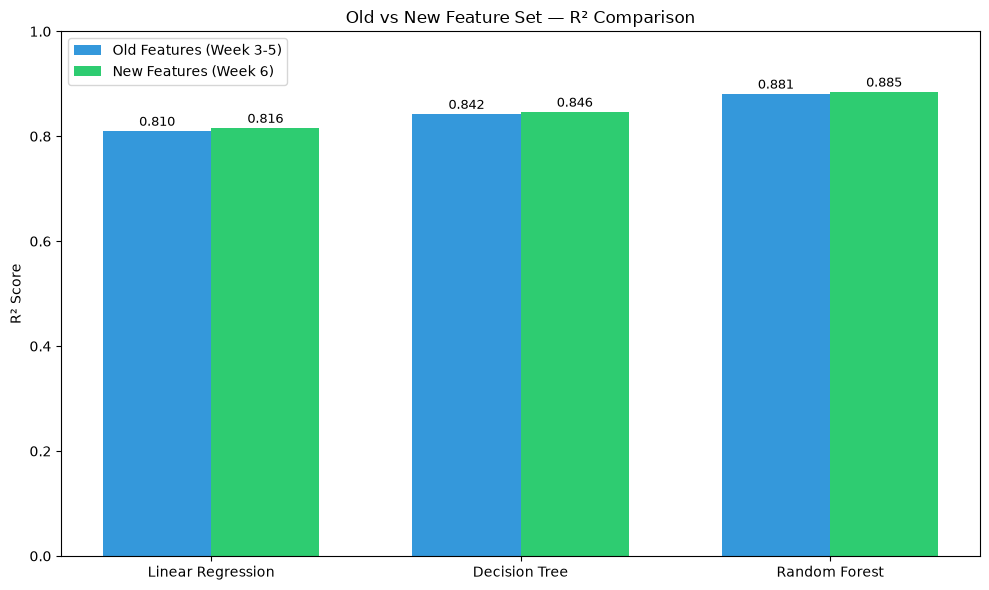

In [30]:
# Grouped bar chart: Old vs New for each model
fig, ax = plt.subplots(figsize=(10, 6))

model_names = ['Linear Regression', 'Decision Tree', 'Random Forest']
x = np.arange(len(model_names))
width = 0.35

# Get scores for each feature set
old_scores = [results_df[(results_df['Model'] == m) &
              (results_df['Feature Set'] == 'Old (Week 3-5)')]['R² Score'].values[0]
              for m in model_names]
new_scores = [results_df[(results_df['Model'] == m) &
              (results_df['Feature Set'] == 'New (Week 6)')]['R² Score'].values[0]
              for m in model_names]

# Draw bars
ax.bar(x - width/2, old_scores, width, label='Old Features (Week 3-5)', color='#3498db')
ax.bar(x + width/2, new_scores, width, label='New Features (Week 6)', color='#2ecc71')

# Add value labels on top of each bar
for i, (old, new) in enumerate(zip(old_scores, new_scores)):
    ax.text(i - width/2, old + 0.01, f'{old:.3f}', ha='center', fontsize=9)
    ax.text(i + width/2, new + 0.01, f'{new:.3f}', ha='center', fontsize=9)

ax.set_ylabel('R² Score')
ax.set_title('Old vs New Feature Set — R² Comparison')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.legend()
ax.set_ylim(0, 1.0)
plt.tight_layout()
plt.show()

## Summary

### What changed in the feature set?

| Change | Details |
|---|---|
| **Added** | `BedBathRatio` (beds ÷ baths), `PropertyAge` (2026 − YearBuilt), `SchoolDistrict` (spatial join) |
| **Removed** | `DaysOnMarket` (hindsight data, per best practices) |

### Key Takeaways
- The **school district** feature adds a more detailed geographic layer than just City or PostalCode.
- **BedBathRatio** captures the balance between bedrooms and bathrooms.
- **PropertyAge** is more intuitive and lets the model learn age-related pricing trends.
- Removing **DaysOnMarket** ensures our model can value properties prior to listing.

### What's next (Week 7)
- Hyperparameter tuning to squeeze more performance out of Random Forest.
- Try Gradient Boosted Trees (XGBoost / LightGBM).